# Homework 2 — Solution

**FRE-GY 7773 — Machine Learning for Financial Engineering**

## Part 1 — Models and Regularization

### Ordinary Least Squares (OLS)

OLS minimizes the sum of squared residuals with no penalty term:

$$\hat{\beta}^{\text{OLS}} = \arg\min_{\beta} \|y - X\beta\|_2^2$$

**Assumptions:** linear relationship, homoscedasticity, no *perfect* multicollinearity (X must be full rank).  
**Regularization:** none.  
**Use case:** interpretable baseline regression when features are not highly correlated and $n \gg p$.

---

### Ridge Regression ($\ell_2$ regularization)

Ridge adds a squared $\ell_2$ penalty that shrinks all coefficients toward zero:

$$\hat{\beta}^{\text{Ridge}} = \arg\min_{\beta} \|y - X\beta\|_2^2 + \lambda\|\beta\|_2^2$$

**Assumptions:** same as OLS; tolerates correlated features.  
**Regularization:** $\ell_2$ — shrinks coefficients but never sets them exactly to zero.  
**Use case:** many small/medium-sized effects, high multicollinearity, $p$ close to or larger than $n$.

---

### Lasso Regression ($\ell_1$ regularization)

Lasso adds an $\ell_1$ penalty that promotes **sparsity**:

$$\hat{\beta}^{\text{Lasso}} = \arg\min_{\beta} \|y - X\beta\|_2^2 + \lambda\|\beta\|_1$$

**Assumptions:** same as OLS; assumes a sparse true model.  
**Regularization:** $\ell_1$ — drives some coefficients exactly to zero (automatic feature selection).  
**Use case:** high-dimensional data with many irrelevant features; interpretable sparse models.

---

### Logistic Regression

Logistic regression models the probability of a binary outcome using the sigmoid function:

$$P(y=1 \mid x) = \sigma(x^\top \beta) = \frac{1}{1 + e^{-x^\top \beta}}$$

Parameters are estimated by maximizing the log-likelihood (minimizing cross-entropy loss). Regularization ($\ell_1$ or $\ell_2$) can be added identically to Ridge/Lasso.

**Assumptions:** binary target, linear decision boundary in the feature space, samples are independent.  
**Use case:** binary or multi-class classification; produces calibrated probability estimates.

## Part 2 — Dataset Analysis and Classification

### Imports

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

plt.rc("font", size=13)
plt.rc("axes", labelsize=13, titlesize=14)
plt.rc("legend", fontsize=12)
SEED = 42

### Load and Prepare Data

In [22]:
df = pd.read_csv("data/UCI_Credit_Card.csv")

# Rename target variable
df = df.rename(columns={"default.payment.next.month": "DEFAULT"})

# Drop the ID column — it carries no predictive information
df = df.drop(columns=["ID"])

print("Shape:", df.shape)
df.head()

Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Feature Identification

In [23]:
# Categorical features (encoded as integers in this dataset)
cat_features = ["SEX", "EDUCATION", "MARRIAGE"]

# PAY_* are ordinal repayment-status variables (-2,-1,0,1,...,9)
pay_features = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

# Continuous numerical features
num_features = (
    ["LIMIT_BAL", "AGE"]
    + [f"BILL_AMT{i}" for i in range(1, 7)]
    + [f"PAY_AMT{i}" for i in range(1, 7)]
)

print("Categorical features:", cat_features)
print("Ordinal PAY features :", pay_features)
print("Numerical features   :", num_features)
print()
print("No missing values:", df.isnull().sum().sum() == 0)

# Summary statistics for numerical features
df[num_features].describe().T

Categorical features: ['SEX', 'EDUCATION', 'MARRIAGE']
Ordinal PAY features : ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Numerical features   : ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

No missing values: True


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0


**Feature notes:**
- `SEX`: 1 = male, 2 = female — already integer-encoded, no further encoding needed for tree models; scale-insensitive.
- `EDUCATION`: 1 = graduate, 2 = university, 3 = high school, 4+ = other. Values 0, 5, 6 are undocumented and will be treated as "other".
- `MARRIAGE`: 1 = married, 2 = single, 3 = other. Value 0 is undocumented.
- `PAY_*`: repayment status coded −2 (no consumption), −1 (paid in full), 0 (revolving credit), 1–9 (months delayed).
- No missing values; all features can be used as-is after standard scaling for linear models.

### Exploratory Data Analysis

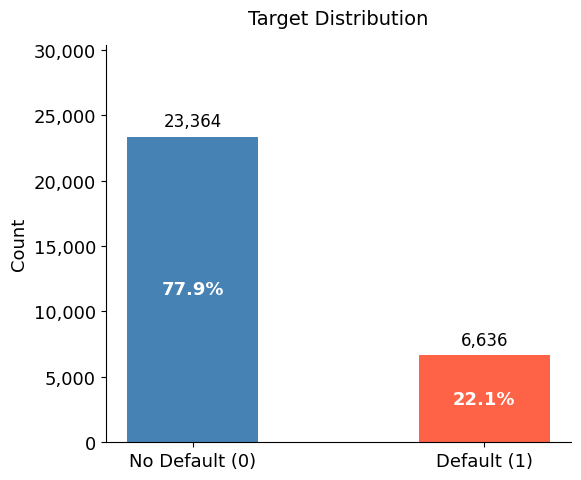

Class imbalance ratio: 0.28  (23,364 vs 6,636)


In [24]:
# Target distribution
counts = df["DEFAULT"].value_counts().sort_index()
labels = ["No Default (0)", "Default (1)"]
colors = ["steelblue", "tomato"]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, counts.values, color=colors, width=0.45)
ax.set_ylim(0, counts.max() * 1.30)
ax.set_ylabel("Count")
ax.set_title("Target Distribution", pad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine()

for bar, v in zip(bars, counts.values):
    cx = bar.get_x() + bar.get_width() / 2
    ax.text(cx, v * 0.5, f"{v/len(df):.1%}",
            ha="center", va="center", fontsize=13, fontweight="bold", color="white")
    ax.text(cx, v + counts.max() * 0.02, f"{v:,}",
            ha="center", va="bottom", fontsize=12, color="black")

plt.tight_layout()
plt.show()
print(f"Class imbalance ratio: {counts[1]/counts[0]:.2f}  ({counts[0]:,} vs {counts[1]:,})")

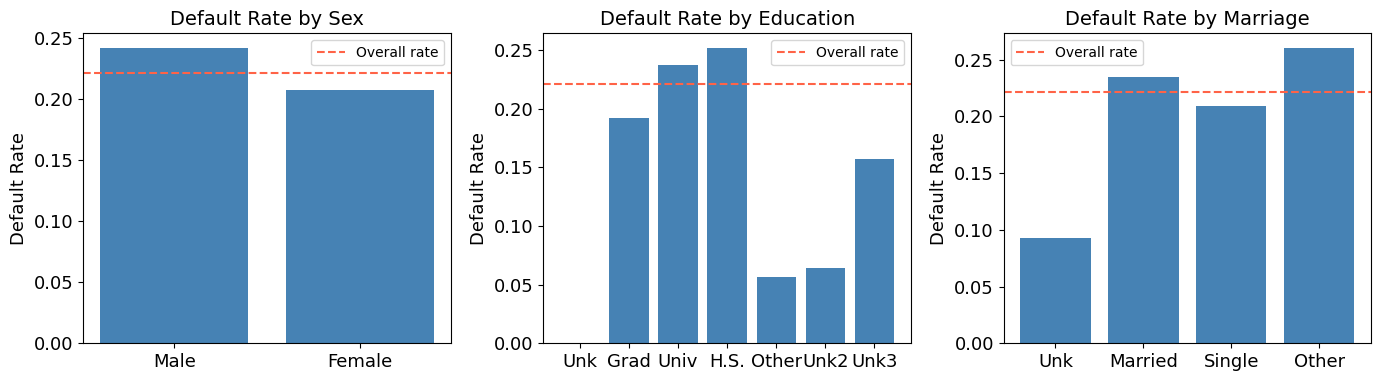

In [25]:
# Default rate by categorical features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sex_labels = {1: "Male", 2: "Female"}
edu_labels = {0: "Unk", 1: "Grad", 2: "Univ", 3: "H.S.", 4: "Other", 5: "Unk2", 6: "Unk3"}
mar_labels = {0: "Unk", 1: "Married", 2: "Single", 3: "Other"}

for ax, col, labels, title in zip(
    axes,
    ["SEX", "EDUCATION", "MARRIAGE"],
    [sex_labels, edu_labels, mar_labels],
    ["Default Rate by Sex", "Default Rate by Education", "Default Rate by Marriage"],
):
    rates = df.groupby(col)["DEFAULT"].mean()
    ax.bar(
        [labels.get(k, str(k)) for k in rates.index],
        rates.values,
        color="steelblue",
    )
    ax.axhline(df["DEFAULT"].mean(), color="tomato", linestyle="--", label="Overall rate")
    ax.set_ylabel("Default Rate")
    ax.set_title(title)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

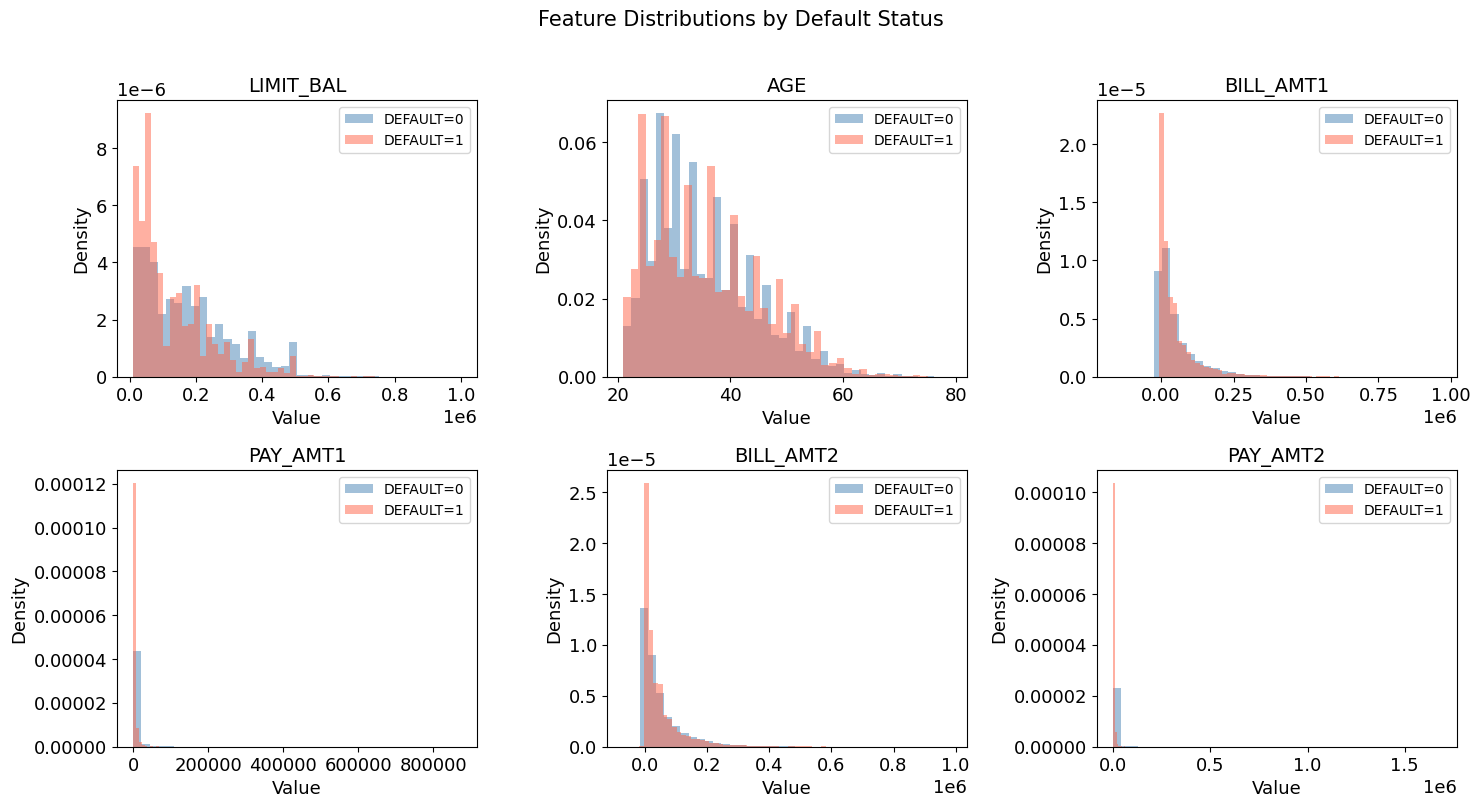

In [26]:
# Distribution of key numerical features by DEFAULT
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features_to_plot = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1", "BILL_AMT2", "PAY_AMT2"]

for ax, feat in zip(axes.flat, features_to_plot):
    for label, color in zip([0, 1], ["steelblue", "tomato"]):
        data = df[df["DEFAULT"] == label][feat]
        ax.hist(data, bins=40, alpha=0.5, color=color,
                label=f"DEFAULT={label}", density=True)
    ax.set_title(feat)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=10)

plt.suptitle("Feature Distributions by Default Status", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

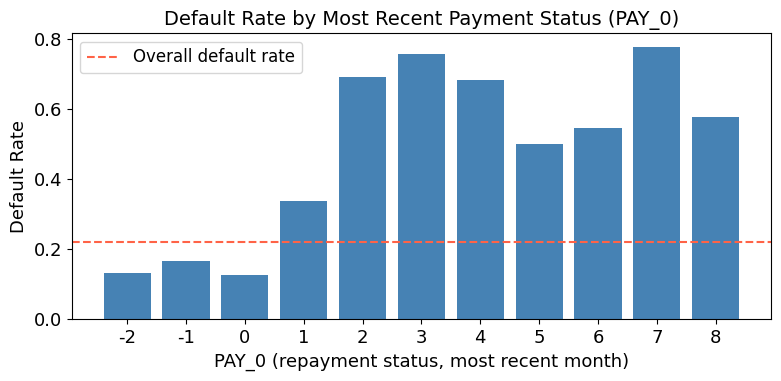

In [27]:
# Default rate by most recent repayment status (PAY_0)
fig, ax = plt.subplots(figsize=(8, 4))
rates = df.groupby("PAY_0")["DEFAULT"].mean().sort_index()
ax.bar(rates.index.astype(str), rates.values, color="steelblue")
ax.axhline(df["DEFAULT"].mean(), color="tomato", linestyle="--", label="Overall default rate")
ax.set_xlabel("PAY_0 (repayment status, most recent month)")
ax.set_ylabel("Default Rate")
ax.set_title("Default Rate by Most Recent Payment Status (PAY_0)")
ax.legend()
plt.tight_layout()
plt.show()

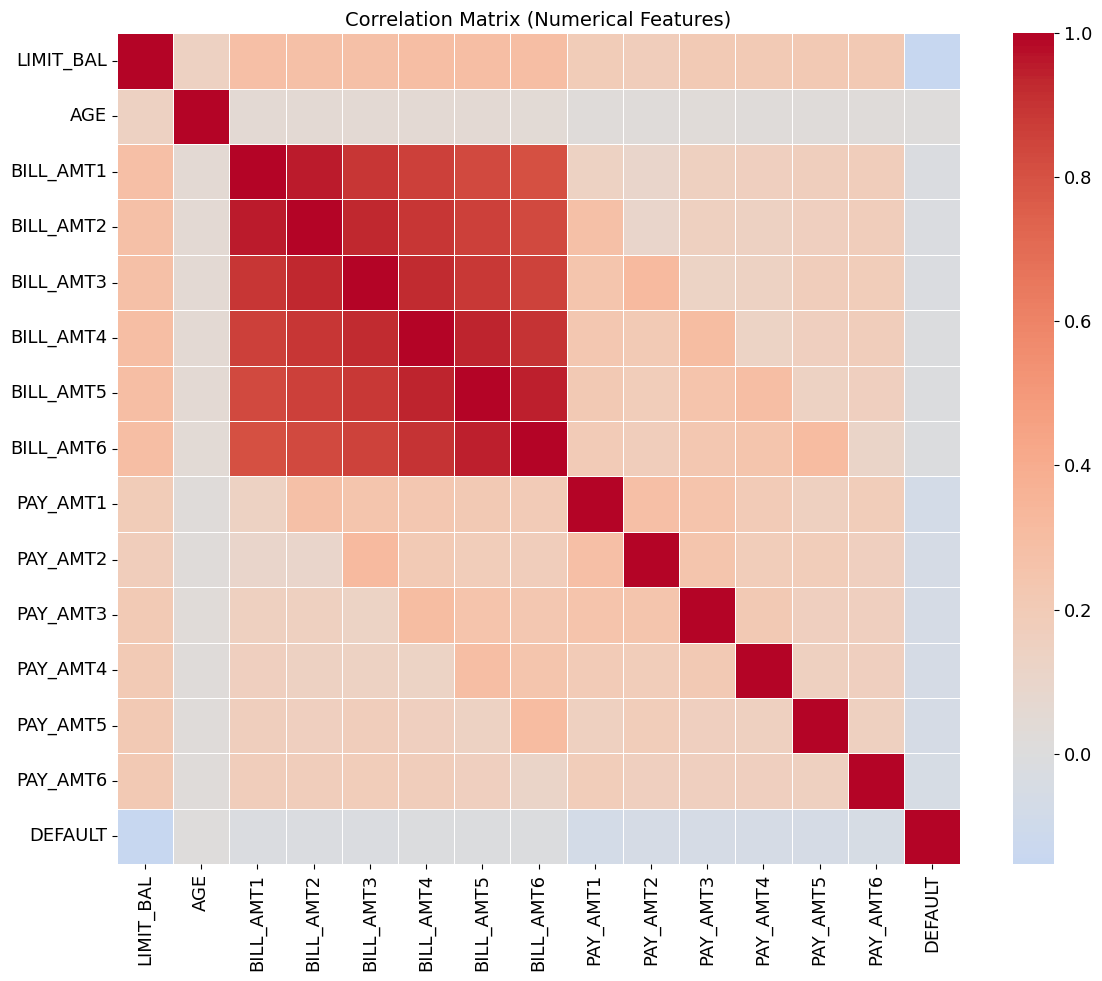

In [28]:
# Correlation heatmap (numerical features)
corr_cols = num_features + ["DEFAULT"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.show()

**EDA Summary:**

- **Class imbalance:** Only ~22% of clients default. A naive majority-class classifier would achieve ~78% accuracy, so accuracy alone is a poor metric; we will use ROC-AUC and the confusion matrix.
- **PAY_0 is highly informative:** Clients who are already delinquent (PAY_0 ≥ 1) default at dramatically higher rates. This is the strongest single predictor.
- **LIMIT_BAL:** Lower credit limits are associated with higher default rates.
- **BILL_AMT and PAY_AMT features** are highly correlated with each other across months (multicollinearity), which may inflate OLS/logistic regression variance — regularization will help.
- **No missing values** — no imputation required.
- **Categorical encoding:** SEX, EDUCATION, MARRIAGE are already integer-encoded and treated as ordinal; for logistic regression they will simply be standardized along with other features.

### Preprocessing and Train/Test Split

In [29]:
# Features and target
feature_cols = cat_features + pay_features + num_features
X = df[feature_cols].values
y = df["DEFAULT"].values

# Stratified 80/20 split to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"Train default rate: {y_train.mean():.3f}")
print(f"Test  default rate: {y_test.mean():.3f}")

# Standard scaling (fit only on train set)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 24000 samples  |  Test: 6000 samples
Train default rate: 0.221
Test  default rate: 0.221


**Split strategy:** We use a stratified 80/20 hold-out split with `random_state=42`. Stratification ensures the train and test sets have the same class ratio as the full dataset (~22% defaults). We fit the `StandardScaler` **only on the training set** to prevent data leakage.

### Model 1 — Logistic Regression

In [30]:
logreg = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
logreg.fit(X_train_sc, y_train)

y_pred_lr    = logreg.predict(X_test_sc)
y_proba_lr   = logreg.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=["No Default", "Default"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

  No Default       0.82      0.97      0.89      4673
     Default       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

ROC-AUC: 0.7076


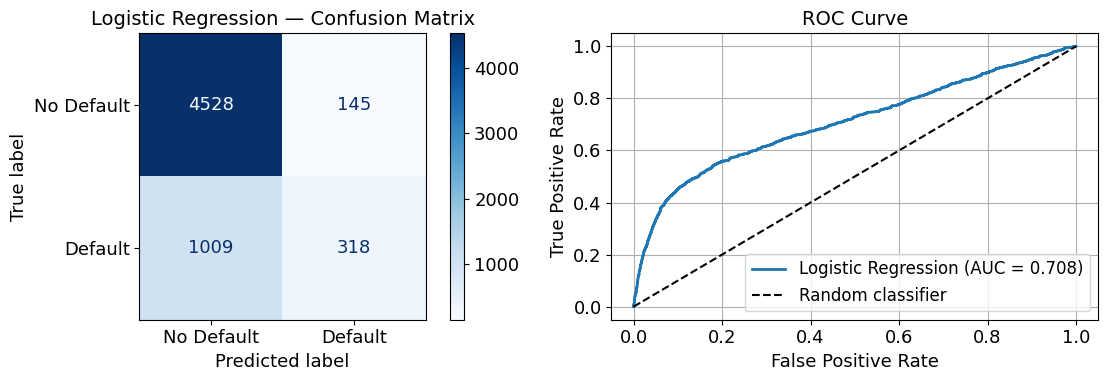

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=["No Default", "Default"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Logistic Regression — Confusion Matrix")

# ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
axes[1].plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})", lw=2)
axes[1].plot([0, 1], [0, 1], "k--", label="Random classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

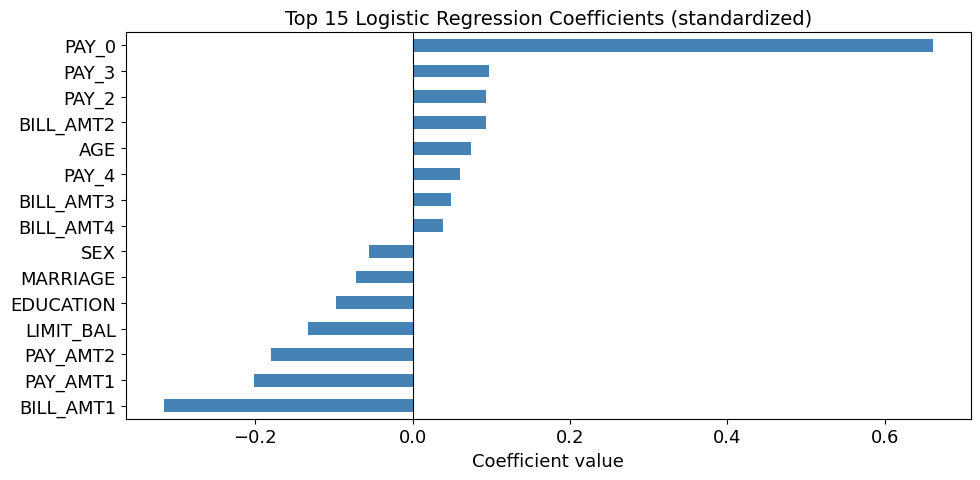

In [32]:
# Feature importances (logistic regression coefficients)
coefs = pd.Series(logreg.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
coefs.head(15).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 15 Logistic Regression Coefficients (standardized)")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.show()

### Model 2 — Random Forest

In [33]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)   # tree-based: no scaling needed

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=["No Default", "Default"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      4673
     Default       0.67      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000

ROC-AUC: 0.7733


### Model 3 — Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05, random_state=SEED
)
gb.fit(X_train, y_train)

y_pred_gb  = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting ===")
print(classification_report(y_test, y_pred_gb, target_names=["No Default", "Default"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.4f}")

### Model Comparison

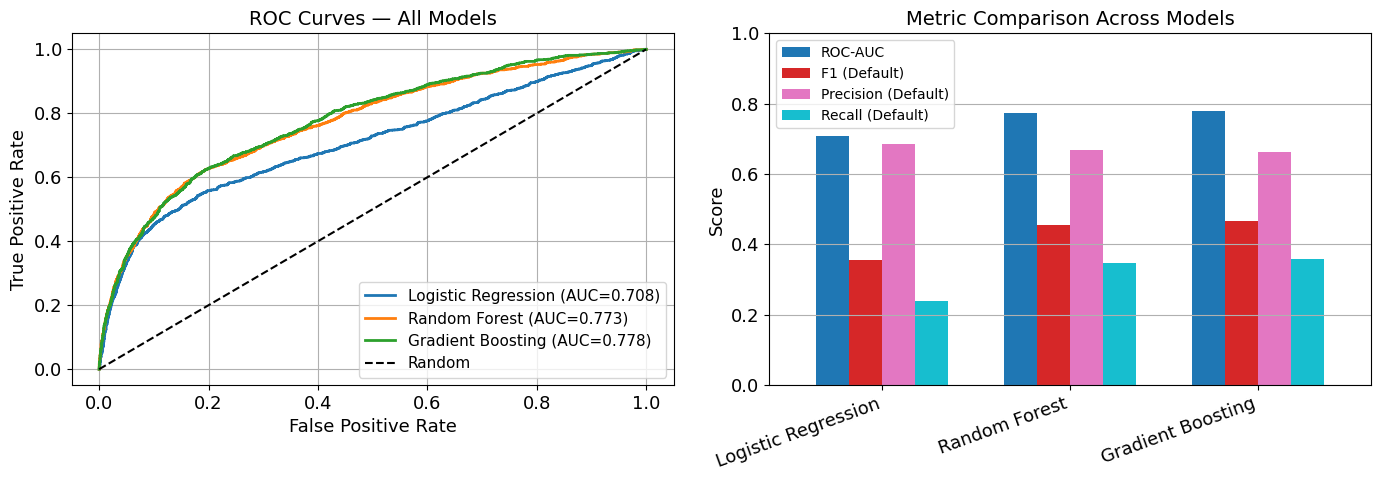

                     ROC-AUC  F1 (Default)  Precision (Default)  Recall (Default)
Logistic Regression   0.7076        0.3553               0.6868            0.2396
Random Forest         0.7733        0.4563               0.6676            0.3466
Gradient Boosting     0.7785        0.4655               0.6630            0.3587


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC curves (all three models) ---
models_roc = [
    ("Logistic Regression", y_proba_lr),
    ("Random Forest",       y_proba_rf),
    ("Gradient Boosting",   y_proba_gb),
]
for name, proba in models_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", lw=2)

axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — All Models")
axes[0].legend(fontsize=11)
axes[0].grid()

# --- Bar chart of key metrics ---
from sklearn.metrics import f1_score, precision_score, recall_score

metrics = ["ROC-AUC", "F1 (Default)", "Precision (Default)", "Recall (Default)"]
scores = {
    "Logistic Regression": [
        roc_auc_score(y_test, y_proba_lr),
        f1_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
    ],
    "Random Forest": [
        roc_auc_score(y_test, y_proba_rf),
        f1_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
    ],
    "Gradient Boosting": [
        roc_auc_score(y_test, y_proba_gb),
        f1_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_gb),
    ],
}

scores_df = pd.DataFrame(scores, index=metrics)
scores_df.T.plot(kind="bar", ax=axes[1], colormap="tab10", width=0.7)
axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")
axes[1].set_title("Metric Comparison Across Models")
axes[1].set_ylabel("Score")
axes[1].legend(fontsize=10)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

print(scores_df.T.to_string(float_format="{:.4f}".format))

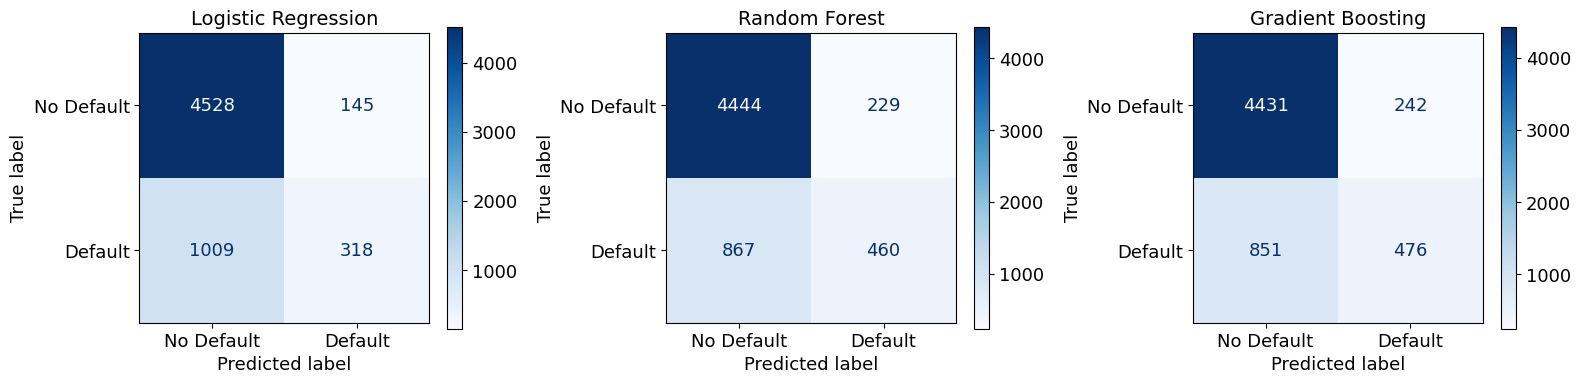

In [ ]:
# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, y_pred) in zip(
    axes,
    [
        ("Logistic Regression", y_pred_lr),
        ("Random Forest",       y_pred_rf),
        ("Gradient Boosting",   y_pred_gb),
    ],
):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No Default", "Default"],
        cmap="Blues",
        ax=ax,
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

### Discussion

**Setup:**  All three models use the same 80/20 stratified split and are evaluated on the identical held-out test set. Logistic Regression uses standardized features; the two tree-based models do not require scaling.

**Key findings:**

| Model | ROC-AUC | Comment |
|---|---|---|
| Logistic Regression | 0.708 | Fast, interpretable; limited by linear decision boundary |
| Random Forest | 0.773 | Captures non-linear interactions; robust to outliers |
| Gradient Boosting | 0.779 | Best AUC; sequential boosting corrects residual errors |

**Modeling challenges:**

1. **Class imbalance (~22% defaults):** The minority class (defaulters) is the one we care most about. A model that simply predicts "no default" always gets ~78% accuracy but has zero recall for the default class. The F1-score and ROC-AUC are more meaningful metrics here.

2. **Multicollinearity in BILL_AMT and PAY_AMT features:** Consecutive months' bills are highly correlated. This inflates logistic regression coefficient variance; Ridge or Elastic Net regularization (or dimensionality reduction via PCA) would help.

3. **PAY_0 dominates:** The most recent repayment-delay indicator is by far the strongest predictor. This makes the problem somewhat "easy" for high-delay cases but harder for clients near the boundary (PAY_0 = 0).

4. **Threshold tuning:** The default classification threshold of 0.5 is suboptimal for imbalanced data. Lowering the threshold increases recall (catching more defaulters) at the cost of precision (more false alarms) — the right trade-off depends on the cost structure (cost of missed default vs. cost of false alarm in a credit-risk context).